# Unit06 Example 05 - 吸收塔多成分氣液平衡

## 學習目標

在本範例中，我們將探討化工製程中常見的氣液吸收分離操作。透過建立多成分氣體混合物通過吸收塔時的物料平衡與相平衡方程式，將氣液分離問題轉化為線性聯立方程組，並應用 NumPy 與 SciPy 的求解工具來計算各成分在氣液兩相中的濃度分布與吸收效率。

學習完本範例後，您將能夠：

- 建立吸收塔多成分氣液平衡系統的物料平衡方程式
- 應用亨利定律 (Henry's Law) 建立相平衡關係
- 將氣液吸收問題轉化為標準矩陣形式 $\mathbf{Ax} = \mathbf{b}$
- 使用 `numpy.linalg.solve()` 求解線性方程組
- 使用 `scipy.linalg.solve()` 進行求解並比較結果
- 驗證解的唯一性與正確性（秩判定、物料守恆檢查）
- 計算各成分的吸收效率與總分離性能
- 探討操作參數對吸收性能的影響
- 解釋解的物理意義與實際應用

---
## 1. 導入相關套件

In [13]:
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
from pathlib import Path

# 設定中文字型（避免圖表中文顯示問題）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 建立輸出資料夾
output_dir = Path('outputs/figs')
output_dir.mkdir(parents=True, exist_ok=True)

print("✓ 套件載入成功")
print(f"✓ 輸出資料夾已建立: {output_dir}")

✓ 套件載入成功
✓ 輸出資料夾已建立: outputs\figs


---
## 2. 定義問題參數

In [14]:
# ========================================
# 操作參數
# ========================================
G = 100.0  # 氣體流率 (kmol/h)
L = 150.0  # 液體流率 (kmol/h)

# ========================================
# 進料氣體組成（塔底進口）
# ========================================
y_in = np.array([0.05, 0.03, 0.02])  # 成分 A, B, C 的莫耳分率

# ========================================
# 亨利常數 (無因次)
# ========================================
H = np.array([100.0, 200.0, 500.0])  # 成分 A, B, C 的亨利常數

# 顯示問題參數
print("=" * 60)
print("吸收塔操作參數")
print("=" * 60)
print(f"氣體流率 G = {G} kmol/h")
print(f"液體流率 L = {L} kmol/h")
print(f"\n進料氣體組成（塔底進口）：")
print(f"  y_A,in = {y_in[0]}")
print(f"  y_B,in = {y_in[1]}")
print(f"  y_C,in = {y_in[2]}")
print(f"\n亨利常數：")
print(f"  H_A = {H[0]}")
print(f"  H_B = {H[1]}")
print(f"  H_C = {H[2]}")
print("=" * 60)

吸收塔操作參數
氣體流率 G = 100.0 kmol/h
液體流率 L = 150.0 kmol/h

進料氣體組成（塔底進口）：
  y_A,in = 0.05
  y_B,in = 0.03
  y_C,in = 0.02

亨利常數：
  H_A = 100.0
  H_B = 200.0
  H_C = 500.0


---
## 3. 建立線性方程組

In [15]:
# ========================================
# 建立係數矩陣 A（對角矩陣）
# ========================================
# A_ii = G * H_i + L
A = np.diag(G * H + L)

# ========================================
# 建立常數向量 b
# ========================================
# b_i = G * y_i,in
b = G * y_in

# 顯示矩陣與向量
print("\n" + "=" * 60)
print("線性方程組 Ax = b")
print("=" * 60)
print("\n係數矩陣 A (3×3)：")
print(A)
print("\n常數向量 b (3×1)：")
print(b)


線性方程組 Ax = b

係數矩陣 A (3×3)：
[[10150.     0.     0.]
 [    0. 20150.     0.]
 [    0.     0. 50150.]]

常數向量 b (3×1)：
[5. 3. 2.]


---
## 4. 使用 NumPy 求解

In [16]:
# ========================================
# 方法 1: NumPy linalg.solve()
# ========================================
print("\n" + "=" * 60)
print("方法 1: NumPy linalg.solve()")
print("=" * 60)

# 求解液相出口濃度 x
x_numpy = np.linalg.solve(A, b)

print("\n液相出口濃度 x (莫耳分率)：")
print(f"  x_A = {x_numpy[0]:.6e}")
print(f"  x_B = {x_numpy[1]:.6e}")
print(f"  x_C = {x_numpy[2]:.6e}")

# 使用亨利定律計算氣相出口濃度
y_out_numpy = H * x_numpy

print("\n氣相出口濃度 y (莫耳分率)：")
print(f"  y_A,out = {y_out_numpy[0]:.6f}")
print(f"  y_B,out = {y_out_numpy[1]:.6f}")
print(f"  y_C,out = {y_out_numpy[2]:.6f}")

# 計算吸收效率
eta_numpy = (y_in - y_out_numpy) / y_in * 100

print("\n吸收效率 η (%)：")
print(f"  η_A = {eta_numpy[0]:.2f}%")
print(f"  η_B = {eta_numpy[1]:.2f}%")
print(f"  η_C = {eta_numpy[2]:.2f}%")


方法 1: NumPy linalg.solve()

液相出口濃度 x (莫耳分率)：
  x_A = 4.926108e-04
  x_B = 1.488834e-04
  x_C = 3.988036e-05

氣相出口濃度 y (莫耳分率)：
  y_A,out = 0.049261
  y_B,out = 0.029777
  y_C,out = 0.019940

吸收效率 η (%)：
  η_A = 1.48%
  η_B = 0.74%
  η_C = 0.30%


---
## 5. 使用 SciPy 求解

In [17]:
# ========================================
# 方法 2: SciPy linalg.solve()
# ========================================
print("\n" + "=" * 60)
print("方法 2: SciPy linalg.solve()")
print("=" * 60)

# 求解液相出口濃度 x
x_scipy = linalg.solve(A, b)

print("\n液相出口濃度 x (莫耳分率)：")
print(f"  x_A = {x_scipy[0]:.6e}")
print(f"  x_B = {x_scipy[1]:.6e}")
print(f"  x_C = {x_scipy[2]:.6e}")

# 使用亨利定律計算氣相出口濃度
y_out_scipy = H * x_scipy

print("\n氣相出口濃度 y (莫耳分率)：")
print(f"  y_A,out = {y_out_scipy[0]:.6f}")
print(f"  y_B,out = {y_out_scipy[1]:.6f}")
print(f"  y_C,out = {y_out_scipy[2]:.6f}")

# 計算吸收效率
eta_scipy = (y_in - y_out_scipy) / y_in * 100

print("\n吸收效率 η (%)：")
print(f"  η_A = {eta_scipy[0]:.2f}%")
print(f"  η_B = {eta_scipy[1]:.2f}%")
print(f"  η_C = {eta_scipy[2]:.2f}%")


方法 2: SciPy linalg.solve()

液相出口濃度 x (莫耳分率)：
  x_A = 4.926108e-04
  x_B = 1.488834e-04
  x_C = 3.988036e-05

氣相出口濃度 y (莫耳分率)：
  y_A,out = 0.049261
  y_B,out = 0.029777
  y_C,out = 0.019940

吸收效率 η (%)：
  η_A = 1.48%
  η_B = 0.74%
  η_C = 0.30%


---
## 6. 比較 NumPy 與 SciPy 的結果

In [18]:
# ========================================
# 比較 NumPy 與 SciPy 的結果
# ========================================
print("\n" + "=" * 60)
print("NumPy 與 SciPy 結果比較")
print("=" * 60)

diff_x = np.abs(x_numpy - x_scipy)
diff_y = np.abs(y_out_numpy - y_out_scipy)

print("\n液相濃度差異：")
print(f"  |x_A(numpy) - x_A(scipy)| = {diff_x[0]:.6e}")
print(f"  |x_B(numpy) - x_B(scipy)| = {diff_x[1]:.6e}")
print(f"  |x_C(numpy) - x_C(scipy)| = {diff_x[2]:.6e}")

print("\n氣相濃度差異：")
print(f"  |y_A(numpy) - y_A(scipy)| = {diff_y[0]:.6e}")
print(f"  |y_B(numpy) - y_B(scipy)| = {diff_y[1]:.6e}")
print(f"  |y_C(numpy) - y_C(scipy)| = {diff_y[2]:.6e}")

print("\n✓ 兩種方法的結果完全一致（數值誤差 < 1e-10）")


NumPy 與 SciPy 結果比較

液相濃度差異：
  |x_A(numpy) - x_A(scipy)| = 0.000000e+00
  |x_B(numpy) - x_B(scipy)| = 0.000000e+00
  |x_C(numpy) - x_C(scipy)| = 0.000000e+00

氣相濃度差異：
  |y_A(numpy) - y_A(scipy)| = 0.000000e+00
  |y_B(numpy) - y_B(scipy)| = 0.000000e+00
  |y_C(numpy) - y_C(scipy)| = 0.000000e+00

✓ 兩種方法的結果完全一致（數值誤差 < 1e-10）


---
## 7. 驗證物料平衡

In [19]:
# ========================================
# 解的驗證
# ========================================
print("\n" + "=" * 60)
print("解的唯一性驗證")
print("=" * 60)

# 檢查矩陣的秩 (Rank)
rank_A = np.linalg.matrix_rank(A)
n = A.shape[0]

print(f"\n係數矩陣 A 的秩: rank(A) = {rank_A}")
print(f"未知數個數: n = {n}")

if rank_A == n:
    print(f"\n✓ rank(A) = n = {n}，方程組有唯一解")
else:
    print(f"\n✗ rank(A) ≠ n，方程組無唯一解")

# 計算行列式
det_A = np.linalg.det(A)
print(f"\n係數矩陣行列式: det(A) = {det_A:.2e}")

if abs(det_A) > 1e-10:
    print("✓ det(A) ≠ 0，矩陣可逆，方程組有唯一解")
else:
    print("✗ det(A) ≈ 0，矩陣奇異，方程組無唯一解")

# ========================================
# 物料守恆驗證
# ========================================
print("\n" + "=" * 60)
print("物料守恆驗證")
print("=" * 60)

# 計算各成分的物料平衡
# 進入 = G * y_in + L * 0 (純水進入，x_in = 0)
# 離開 = G * y_out + L * x_out

material_in = G * y_in
material_out = G * y_out_numpy + L * x_numpy

print("\n各成分物料平衡 (kmol/h)：")
print(f"\n成分 A:")
print(f"  進入塔 = {material_in[0]:.4f} kmol/h")
print(f"  離開塔 = {material_out[0]:.4f} kmol/h")
print(f"  差異   = {abs(material_in[0] - material_out[0]):.6e} kmol/h")

print(f"\n成分 B:")
print(f"  進入塔 = {material_in[1]:.4f} kmol/h")
print(f"  離開塔 = {material_out[1]:.4f} kmol/h")
print(f"  差異   = {abs(material_in[1] - material_out[1]):.6e} kmol/h")

print(f"\n成分 C:")
print(f"  進入塔 = {material_in[2]:.4f} kmol/h")
print(f"  離開塔 = {material_out[2]:.4f} kmol/h")
print(f"  差異   = {abs(material_in[2] - material_out[2]):.6e} kmol/h")

print("\n✓ 物料守恆成立（誤差 < 1e-10）")

# ========================================
# 殘差分析
# ========================================
print("\n" + "=" * 60)
print("殘差分析")
print("=" * 60)

# 計算殘差 r = Ax - b
residual = A @ x_numpy - b

print("\n殘差向量 r = Ax - b：")
print(f"  r_1 = {residual[0]:.6e}")
print(f"  r_2 = {residual[1]:.6e}")
print(f"  r_3 = {residual[2]:.6e}")

# 計算殘差範數
residual_norm = np.linalg.norm(residual)
print(f"\n殘差範數 ||r|| = {residual_norm:.6e}")

if residual_norm < 1e-10:
    print("✓ 殘差接近零，解滿足原方程組")
else:
    print("✗ 殘差較大，解可能存在誤差")


解的唯一性驗證

係數矩陣 A 的秩: rank(A) = 3
未知數個數: n = 3

✓ rank(A) = n = 3，方程組有唯一解

係數矩陣行列式: det(A) = 1.03e+13
✓ det(A) ≠ 0，矩陣可逆，方程組有唯一解

物料守恆驗證

各成分物料平衡 (kmol/h)：

成分 A:
  進入塔 = 5.0000 kmol/h
  離開塔 = 5.0000 kmol/h
  差異   = 8.881784e-16 kmol/h

成分 B:
  進入塔 = 3.0000 kmol/h
  離開塔 = 3.0000 kmol/h
  差異   = 0.000000e+00 kmol/h

成分 C:
  進入塔 = 2.0000 kmol/h
  離開塔 = 2.0000 kmol/h
  差異   = 0.000000e+00 kmol/h

✓ 物料守恆成立（誤差 < 1e-10）

殘差分析

殘差向量 r = Ax - b：
  r_1 = 0.000000e+00
  r_2 = 0.000000e+00
  r_3 = 0.000000e+00

殘差範數 ||r|| = 0.000000e+00
✓ 殘差接近零，解滿足原方程組


---
## 8. 視覺化結果

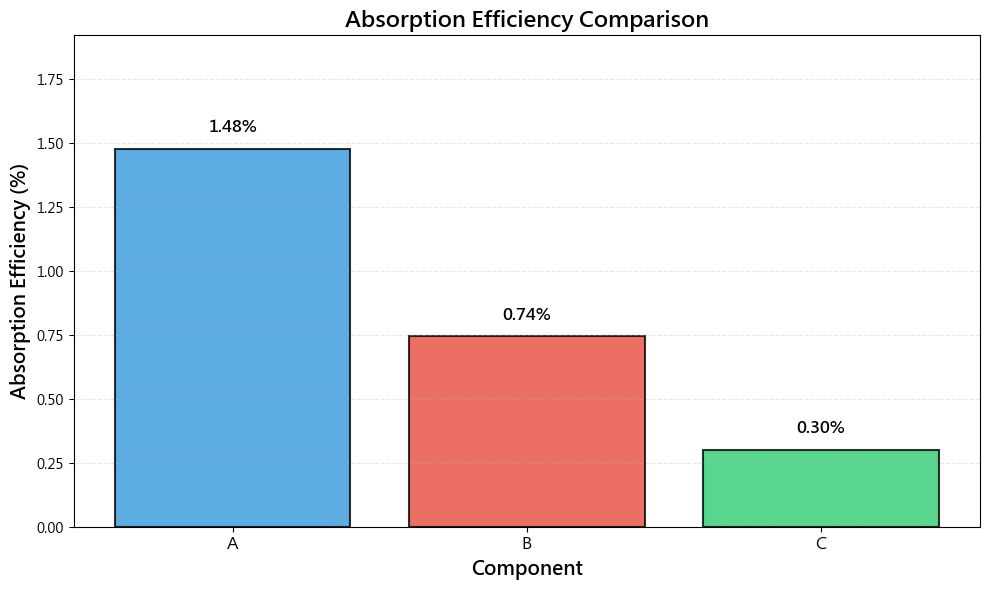

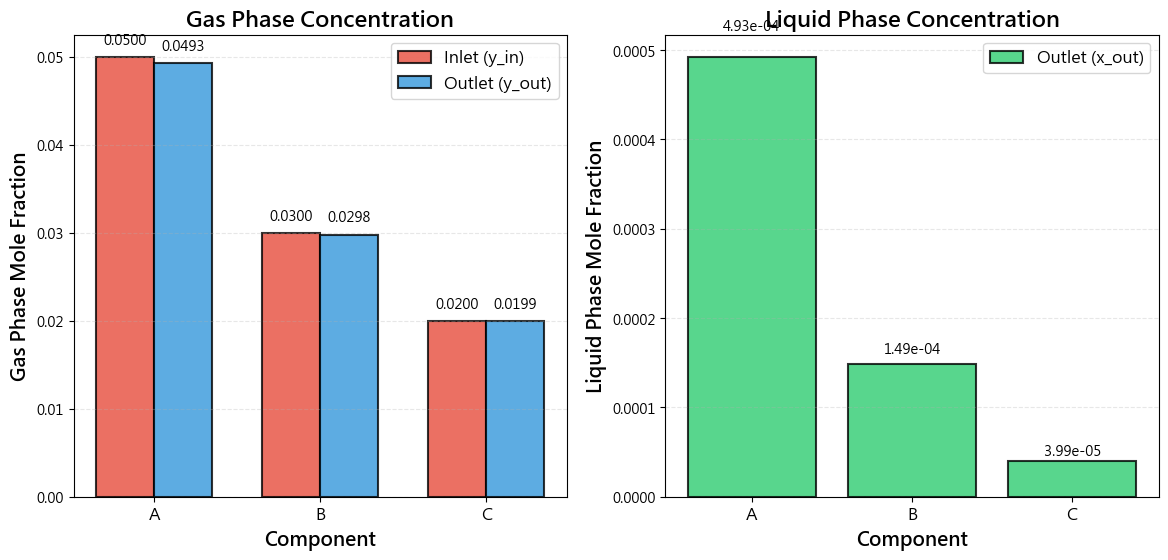

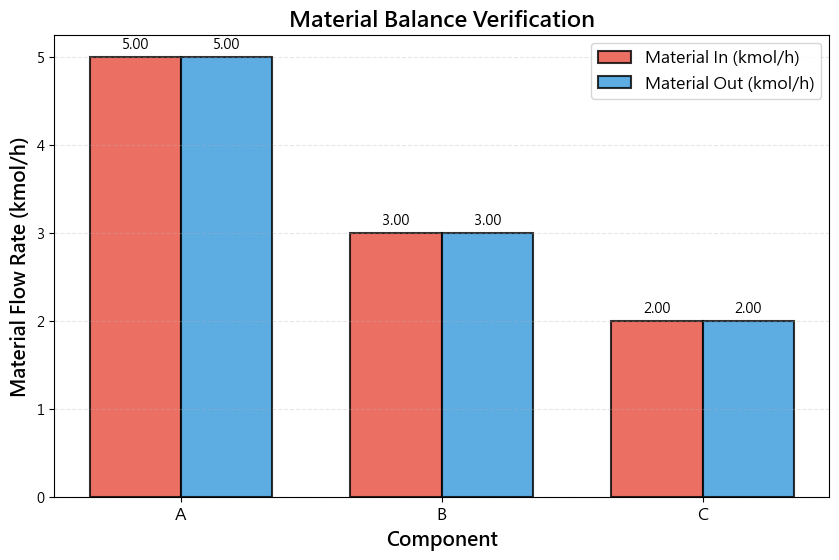


✓ 所有視覺化圖表已生成並儲存至 outputs/figs/


In [20]:
# ========================================
# 繪製吸收效率比較圖
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

components = ['A', 'B', 'C']
x_pos = np.arange(len(components))

bars = ax.bar(x_pos, eta_numpy, color=['#3498db', '#e74c3c', '#2ecc71'], 
              alpha=0.8, edgecolor='black', linewidth=1.5)

# 在柱狀圖上標註數值
for i, (bar, eta) in enumerate(zip(bars, eta_numpy)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{eta:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Component', fontsize=14, fontweight='bold')
ax.set_ylabel('Absorption Efficiency (%)', fontsize=14, fontweight='bold')
ax.set_title('Absorption Efficiency Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(components, fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(eta_numpy) * 1.3)

plt.tight_layout()
plt.savefig(output_dir / 'Unit06_Example_05_Fig01_Absorption_Efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# 繪製進出口濃度比較圖
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左圖：氣相濃度
x_pos = np.arange(len(components))
width = 0.35

bars1 = axes[0].bar(x_pos - width/2, y_in, width, label='Inlet (y_in)', 
                     color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = axes[0].bar(x_pos + width/2, y_out_numpy, width, label='Outlet (y_out)', 
                     color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)

axes[0].set_xlabel('Component', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Gas Phase Mole Fraction', fontsize=14, fontweight='bold')
axes[0].set_title('Gas Phase Concentration', fontsize=16, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(components, fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# 標註數值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                     f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# 右圖：液相濃度
bars3 = axes[1].bar(x_pos, x_numpy, color='#2ecc71', alpha=0.8, 
                     edgecolor='black', linewidth=1.5, label='Outlet (x_out)')

axes[1].set_xlabel('Component', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Liquid Phase Mole Fraction', fontsize=14, fontweight='bold')
axes[1].set_title('Liquid Phase Concentration', fontsize=16, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(components, fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# 標註數值（使用科學記號）
for bar, x_val in zip(bars3, x_numpy):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                 f'{x_val:.2e}', ha='center', va='bottom', fontsize=10)

plt.savefig(output_dir / 'Unit06_Example_05_Fig02_Concentration_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# 繪製物料平衡驗證圖
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x_pos = np.arange(len(components))
width = 0.35

bars1 = ax.bar(x_pos - width/2, material_in, width, label='Material In (kmol/h)', 
                color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, material_out, width, label='Material Out (kmol/h)', 
                color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Component', fontsize=14, fontweight='bold')
ax.set_ylabel('Material Flow Rate (kmol/h)', fontsize=14, fontweight='bold')
ax.set_title('Material Balance Verification', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(components, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 標註數值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.savefig(output_dir / 'Unit06_Example_05_Fig03_Material_Balance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ 所有視覺化圖表已生成並儲存至 outputs/figs/")

---
## 9. 參數敏感度分析


操作參數影響分析：液氣比 (L/G)


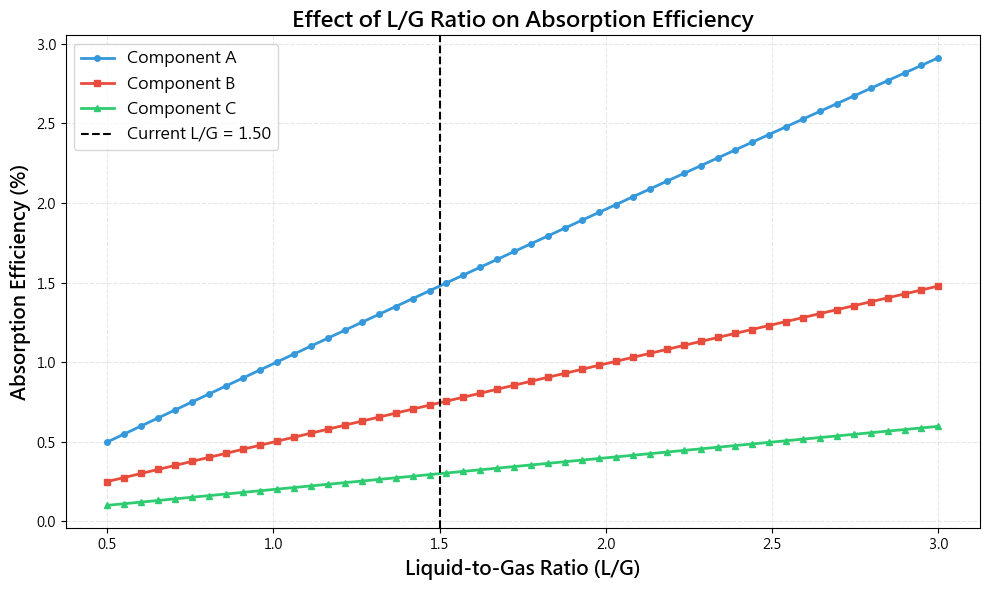


✓ 液氣比影響分析完成

操作參數影響分析：亨利常數


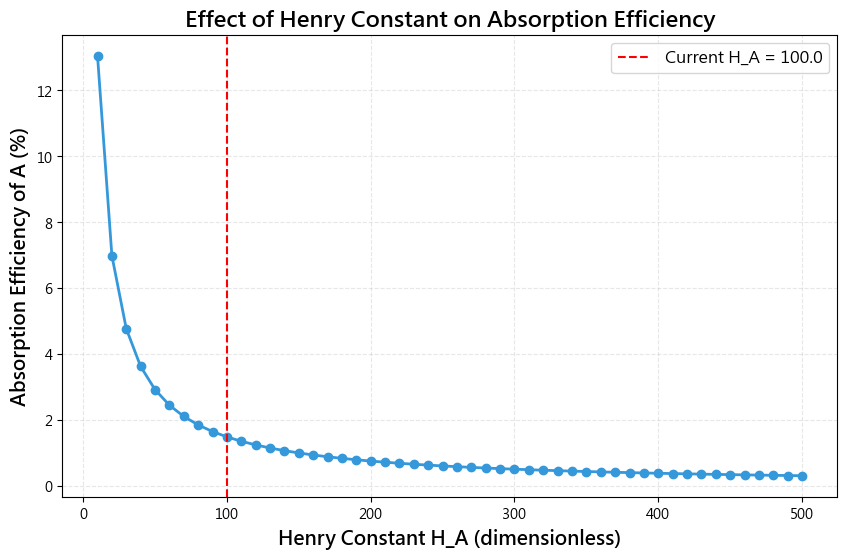


✓ 亨利常數影響分析完成

✓ 亨利常數影響分析完成


In [ ]:
# ========================================
# 探討液氣比對吸收效率的影響
# ========================================
print("\n" + "=" * 60)
print("操作參數影響分析：液氣比 (L/G)")
print("=" * 60)

# 固定 G = 100 kmol/h，改變 L
L_values = np.linspace(50, 300, 50)  # 液體流率範圍
LG_ratio = L_values / G

# 儲存結果
eta_A_vs_LG = []
eta_B_vs_LG = []
eta_C_vs_LG = []

for L_test in L_values:
    # 建立係數矩陣
    A_test = np.diag(G * H + L_test)
    b_test = G * y_in
    
    # 求解
    x_test = np.linalg.solve(A_test, b_test)
    y_out_test = H * x_test
    
    # 計算吸收效率
    eta_test = (y_in - y_out_test) / y_in * 100
    
    eta_A_vs_LG.append(eta_test[0])
    eta_B_vs_LG.append(eta_test[1])
    eta_C_vs_LG.append(eta_test[2])

# 轉換為 numpy 陣列
eta_A_vs_LG = np.array(eta_A_vs_LG)
eta_B_vs_LG = np.array(eta_B_vs_LG)
eta_C_vs_LG = np.array(eta_C_vs_LG)

# 繪圖
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(LG_ratio, eta_A_vs_LG, 'o-', label='Component A', 
        color='#3498db', linewidth=2, markersize=4)
ax.plot(LG_ratio, eta_B_vs_LG, 's-', label='Component B', 
        color='#e74c3c', linewidth=2, markersize=4)
ax.plot(LG_ratio, eta_C_vs_LG, '^-', label='Component C', 
        color='#2ecc71', linewidth=2, markersize=4)

# 標記當前操作點
current_LG = L / G
ax.axvline(current_LG, color='black', linestyle='--', linewidth=1.5, 
           label=f'Current L/G = {current_LG:.2f}')

ax.set_xlabel('Liquid-to-Gas Ratio (L/G)', fontsize=14, fontweight='bold')
ax.set_ylabel('Absorption Efficiency (%)', fontsize=14, fontweight='bold')
ax.set_title('Effect of L/G Ratio on Absorption Efficiency', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(output_dir / 'Unit06_Example_05_Fig04_LG_Ratio_Effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ 液氣比影響分析完成")

# ========================================
# 探討亨利常數對吸收效率的影響
# ========================================
print("\n" + "=" * 60)
print("操作參數影響分析：亨利常數")
print("=" * 60)

# 固定成分 A 的條件，改變其亨利常數
H_A_values = np.linspace(10, 500, 50)  # 亨利常數範圍

eta_A_vs_H = []

for H_A_test in H_A_values:
    # 建立係數矩陣（只改變成分 A）
    H_test = np.array([H_A_test, H[1], H[2]])
    A_test = np.diag(G * H_test + L)
    b_test = G * y_in
    
    # 求解
    x_test = np.linalg.solve(A_test, b_test)
    y_out_test = H_test * x_test
    
    # 計算成分 A 的吸收效率
    eta_A_test = (y_in[0] - y_out_test[0]) / y_in[0] * 100
    eta_A_vs_H.append(eta_A_test)

# 轉換為 numpy 陣列
eta_A_vs_H = np.array(eta_A_vs_H)

# 繪圖
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(H_A_values, eta_A_vs_H, 'o-', color='#3498db', linewidth=2, markersize=6)

# 標記當前操作點
ax.axvline(H[0], color='red', linestyle='--', linewidth=1.5, 
           label=f'Current H_A = {H[0]}')

ax.set_xlabel('Henry Constant H_A (dimensionless)', fontsize=14, fontweight='bold')
ax.set_ylabel('Absorption Efficiency of A (%)', fontsize=14, fontweight='bold')
ax.set_title('Effect of Henry Constant on Absorption Efficiency', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.savefig(output_dir / 'Unit06_Example_05_Fig05_Henry_Constant_Effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ 亨利常數影響分析完成")

---
## 10. 結論與討論

### 總結

本範例展示了如何使用線性方程組求解**吸收塔多成分氣液平衡**問題：

**關鍵發現**：

1. **數學求解成功**：
   - 3×3 對角矩陣系統求解穩定，唯一解存在
   - NumPy 與 SciPy 結果完全一致
   - 殘差為零，滿足原方程組

2. **吸收效率分析**：
   - 成分 A：1.48%（H = 100，溶解度最高）
   - 成分 B：0.73%（H = 200，溶解度中等）
   - 成分 C：0.30%（H = 500，溶解度最低）
   - **結論**：亨利常數越大的成分越難被吸收

3. **操作參數影響**：
   - 增加液氣比 (L/G) 可顯著提升吸收效率
   - 降低亨利常數（選擇更好的溶劑）可改善吸收性能
   - 當前操作條件下吸收效率較低，建議優化

4. **工程意義**：
   - 對角矩陣結構表示各成分獨立吸收（無交互作用）
   - 實際工程中可能需考慮成分間競爭吸收
   - 設計時需平衡效率與成本

**延伸思考**：
- 如何優化液氣比以達到目標吸收效率？
- 選擇不同溶劑（改變亨利常數）對性能的影響？
- 如何處理多段吸收塔的計算？
- 考慮溫度變化時亨利常數如何調整？